# Notebook projet 1 - El Nino / La Nina (Equatorial Pacific)

In [1]:
!pip install basemap

In [11]:
%matplotlib inline
%pylab inline
from mpl_toolkits.basemap import Basemap
import sklearn
import pandas as pd
from scipy.stats.mstats import zscore
import warnings
warnings.filterwarnings("ignore") # disable warnings
pylab.rcParams['figure.figsize']=(10,10) # graph size
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_absolute_error, mean_squared_error

Populating the interactive namespace from numpy and matplotlib


In [ ]:
# function to plot images
def plot_im(lon,lat,im,size_points,var_name,rect_coords=None, title=None):

    #rect_coords : tuple (lon_min, lon_max, lat_min, lat_max) pour définir un rectangle à tracer (facultatif).

    # transform to arrays (just in case)
    lon=array(lon)
    lat=array(lat)
    im=array(im)

    # Determine the colormap based on the range of im
    if nanmin(im) >= -15 and nanmax(im) <= 15:
        cmap = 'seismic'
    else:
        cmap = 'jet'

    if max(lon)-min(lon)<200:
      # Mercator projection (for small zone)
      m=Basemap(projection='merc',llcrnrlat=nanmin(lat),urcrnrlat=nanmax(lat),\
                llcrnrlon=nanmin(lon),urcrnrlon=nanmax(lon),lat_0=(nanmax(lat)+nanmin(lat))*0.5,\
                lon_0=(nanmax(lon)+nanmin(lon))*0.5,resolution='l')

    else:
      # Orthogonal projection (for large zone)
      m=Basemap(projection='ortho',lat_0=0,lon_0=0,resolution='l')
    # you can use other projections (see https://matplotlib.org/basemap/users/mapsetup.html)

    # transform (lon,lat) to (x,y)
    x,y=m(lon,lat)

    # plot
    im=ma.masked_where(isnan(im),im)
    res=m.scatter(x,y,size_points,im,'o',alpha=1,cmap=cmap,lw=0)
    m.drawcoastlines()
    m.fillcontinents()
    parallels = linspace(nanmin(lat),nanmax(lat),15)
    meridians = linspace(nanmin(lon),nanmax(lon),15)
    #m.drawparallels(parallels,labels=[1,0,0,1],fontsize=10)
    #m.drawmeridians(meridians,labels=[1,0,0,1],fontsize=10)
    cb=m.colorbar(res,location="right")
    cb.set_label(var_name,fontsize=15)

    # Draw rectangle if coordinates are provided
    if rect_coords:
        lon_min, lon_max, lat_min, lat_max = rect_coords
        # Transform rectangle corners to map coordinates
        rect_x = [lon_min, lon_max, lon_max, lon_min, lon_min]
        rect_y = [lat_min, lat_min, lat_max, lat_max, lat_min]
        rect_x, rect_y = m(rect_x, rect_y)
        # Plot rectangle
        m.plot(rect_x, rect_y, linestyle='--', linewidth=2, color='k', label='Zone Niño 3.4')

        # Add a legend for the rectangle
        plt.legend(loc='lower left', fontsize=10)

    if title:
        plt.title(title, fontsize=18)

# function to plot time series
def plot_ts(time,SST,line_type,var_name):

    # plot
    plot_date(time,SST,line_type)
    xlabel('Time',fontsize=15)
    ylabel(var_name,fontsize=15)

In [3]:
import os
os.environ['USE_AUTH_EPHEM'] = '0'

from google.colab import auth
auth.authenticate_user()

In [7]:
%%bigquery output --project alert-ground-261008
SELECT time, AVG(sst) AS mean_sst, STDDEV(sst) as std_sst
FROM bdo2020.bdo2020.1998_2015
WHERE lon>190 AND lon<240 AND lat>-5 AND lat<5
GROUP BY time
ORDER BY time

Query is running:   0%|          |

Downloading:   0%|          |

In [21]:
enso_ts_mean = output.mean_sst
mean = enso_ts_mean.mean()
enso_ts_mean = enso_ts_mean - mean # normalizing
time_ts=output.time

In [ ]:
time_ts

,time
0,729390.0
1,729391.0
2,729392.0
3,729393.0
4,729394.0
...,...
6569,735959.0
6570,735960.0
6571,735961.0
6572,735962.0


In [ ]:
start_year = 1998
time_ts_years = start_year + (time_ts - time_ts[0]) / 365
time_ts_years

,time
0,1998.000000
1,1998.002740
2,1998.005479
3,1998.008219
4,1998.010959
...,...
6569,2015.997260
6570,2016.000000
6571,2016.002740
6572,2016.005479


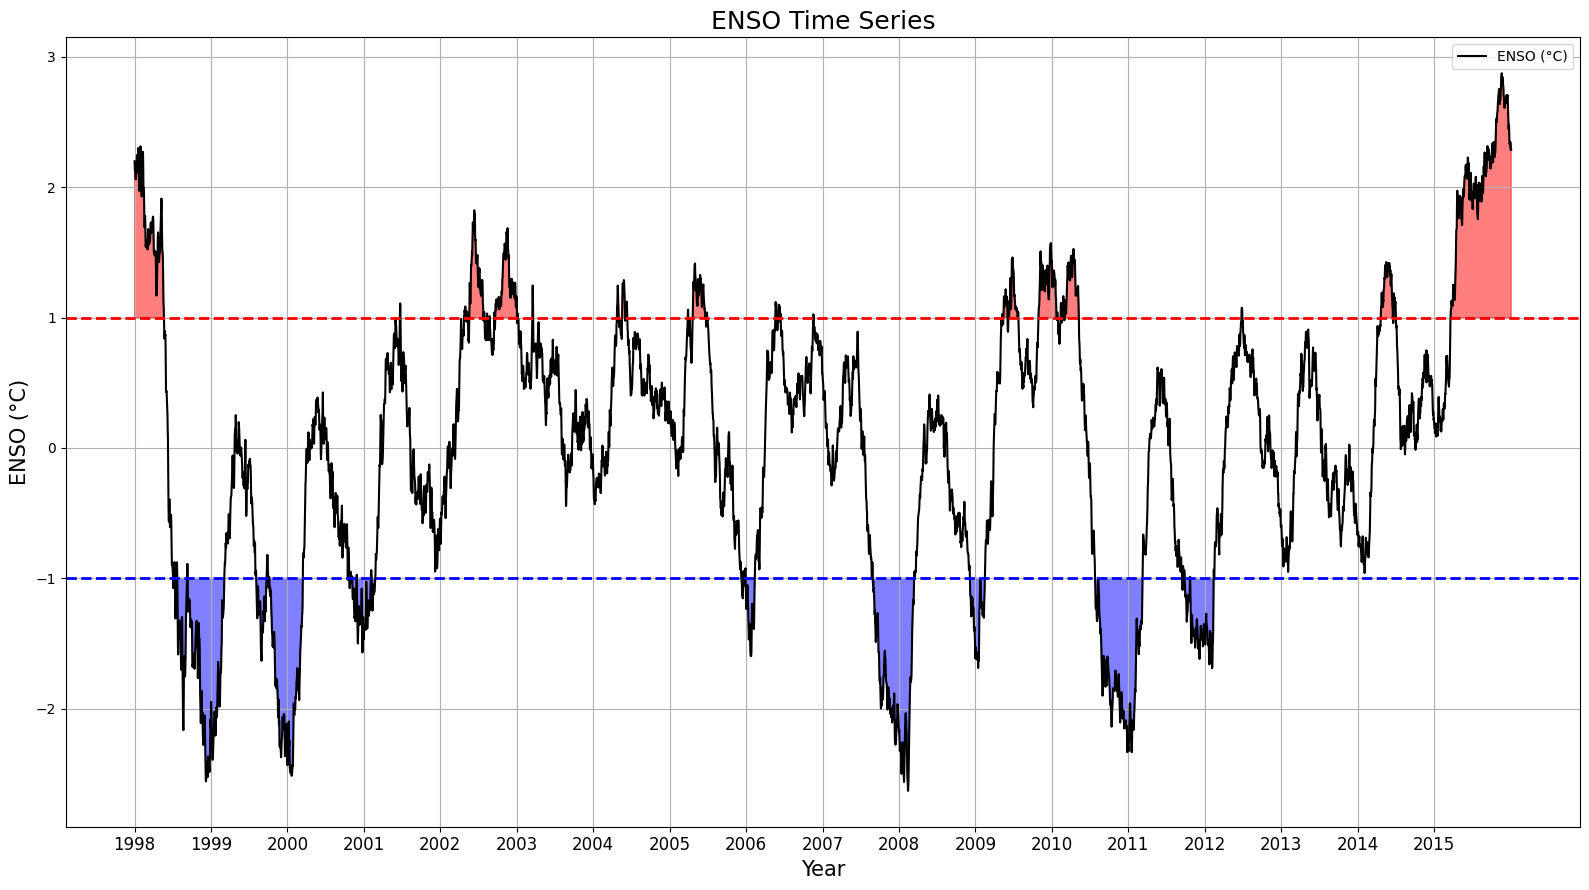

In [ ]:
# Tracer la courbe en noir
plt.figure(figsize=(16, 9))
plt.plot(time_ts_years, enso_ts_mean, '-k', markersize=5, label='ENSO (°C)')  # '-k' pour noir

# Ajouter les lignes horizontales à y=1 et y=-1
plt.axhline(y=1, color='red', linestyle='--', linewidth=2)
plt.axhline(y=-1, color='blue', linestyle='--', linewidth=2)

# Colorier la partie supérieure à 1 en rouge
plt.fill_between(time_ts_years, enso_ts_mean, 1, where=(enso_ts_mean > 1), color='red', alpha=0.5)

# Colorier la partie inférieure à -1 en bleu
plt.fill_between(time_ts_years, enso_ts_mean, -1, where=(enso_ts_mean < -1), color='blue', alpha=0.5)

# Ajouter des labels et un titre
plt.xlabel('Year', fontsize=15)
plt.ylabel('ENSO (°C)', fontsize=15)
plt.title('ENSO Time Series', fontsize=18)
plt.xticks(np.arange(1998, 2016, 1), fontsize=12)

# Ajouter une légende
plt.legend()

# Afficher la grille
plt.grid(True)

# Ajuster la mise en page et afficher
plt.tight_layout()
plt.show()




In [ ]:
el_nino = output[["time", "mean_sst"]][output["mean_sst"] > 1]

In [ ]:
peak_day = output.iloc[output["mean_sst"].idxmax()]["time"]
opposite_peak_day = output.iloc[output["mean_sst"].idxmin()]["time"]

In [ ]:
print("peak day", peak_day)
print("opposite peak day",opposite_peak_day)

peak day 735918.0
opposite peak day 733083.0


In [6]:
%%bigquery avg_map --project alert-ground-261008
SELECT lon,lat, avg(sst) as mean_sst, STDDEV(sst) as std_sst
FROM bdo2020.bdo2020.1998_2015
WHERE lon>180 AND lon<300 AND lat>-20 AND lat<20
GROUP BY lon,lat

Query is running:   0%|          |

Downloading:   0%|          |

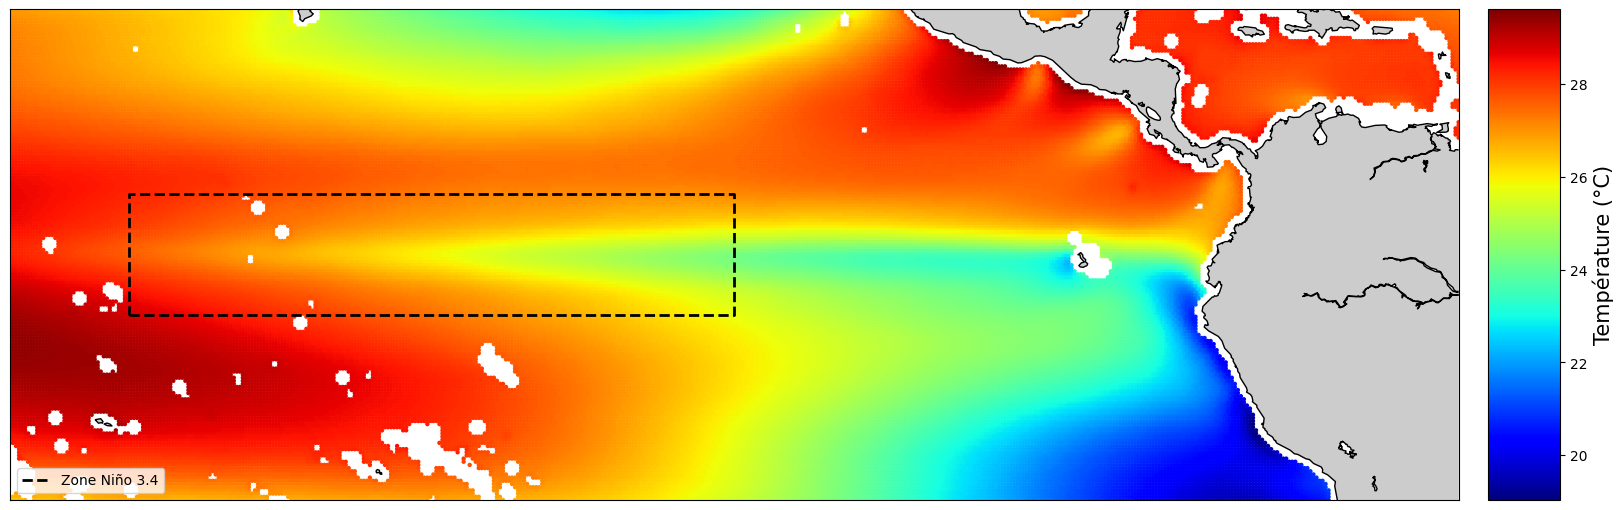

In [ ]:
lon_min_Nino34, lon_max_Nino34, lat_min_Nino34, lat_max_Nino34 = 190, 240, -5, 5
plot_im(avg_map.lon, avg_map.lat, avg_map.mean_sst, 10, 'Température (°C)',rect_coords=(lon_min_Nino34, lon_max_Nino34, lat_min_Nino34, lat_max_Nino34),title'Episode El Niño')

Ici on trace la carte de l'ENSO pour un épisode El Nino.

In [ ]:
%%bigquery data_day_EL_NINO --project alert-ground-261008
SELECT lon, lat, sst
FROM bdo2020.bdo2020.1998_2015
WHERE lon<300 and lon>180 and lat<20 and lat>-20 and time = 735723.0

Query is running:   0%|          |

Downloading:   0%|          |

Les coordonnées de la zone Nino34 sont (5N-5S)(170-120W).
D'après le site du laboratoire des Sciences Physique du NOAA https://psl.noaa.gov/data/timeseries/month/Nino34/

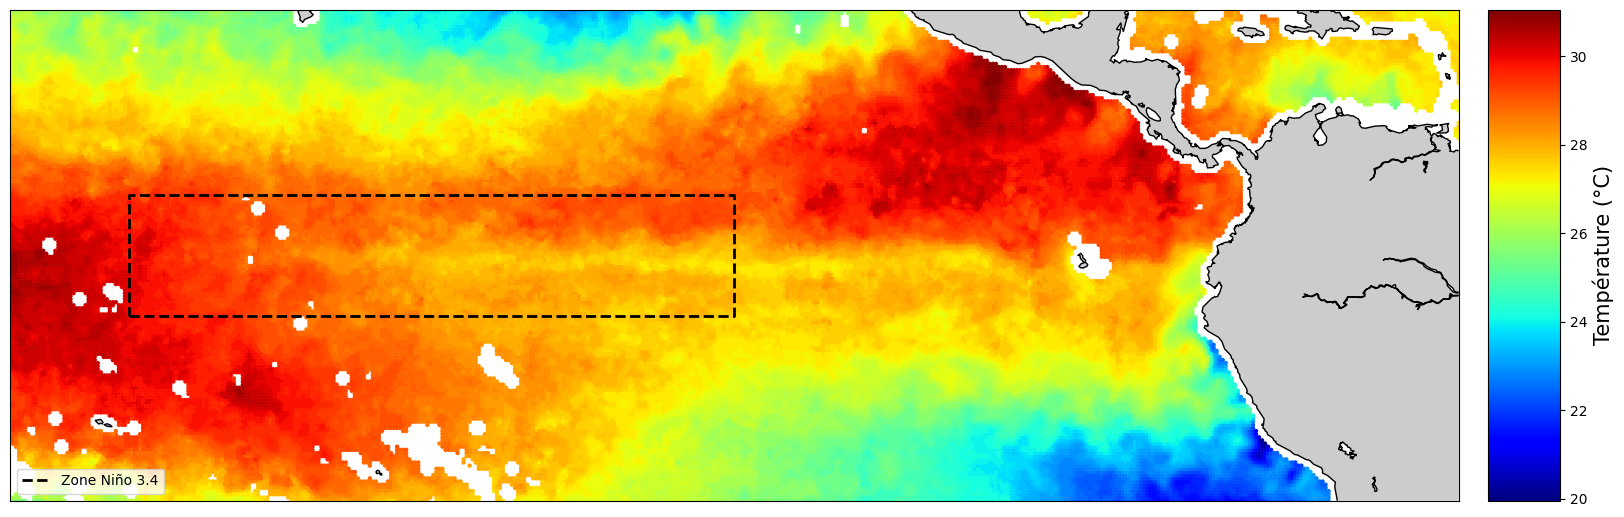

In [ ]:
lon_min_Nino34, lon_max_Nino34, lat_min_Nino34, lat_max_Nino34 = 190, 240, -5, 5
plot_im(data_day_EL_NINO.lon, data_day_EL_NINO.lat, data_day_EL_NINO.sst, 10, 'Température (°C)', rect_coords=(lon_min_Nino34, lon_max_Nino34, lat_min_Nino34, lat_max_Nino34))

In [ ]:
%%bigquery el_nino_map --project alert-ground-261008
SELECT lon,lat, sst
FROM bdo2020.bdo2020.1998_2015
WHERE lon>180 AND lon<300 AND lat>-20 AND lat<20 AND time = 735723.0
GROUP BY lon,lat, sst

Query is running:   0%|          |

Downloading:   0%|          |

In [ ]:
anomaly_map = avg_map["mean_sst"] - el_nino_map["sst"]

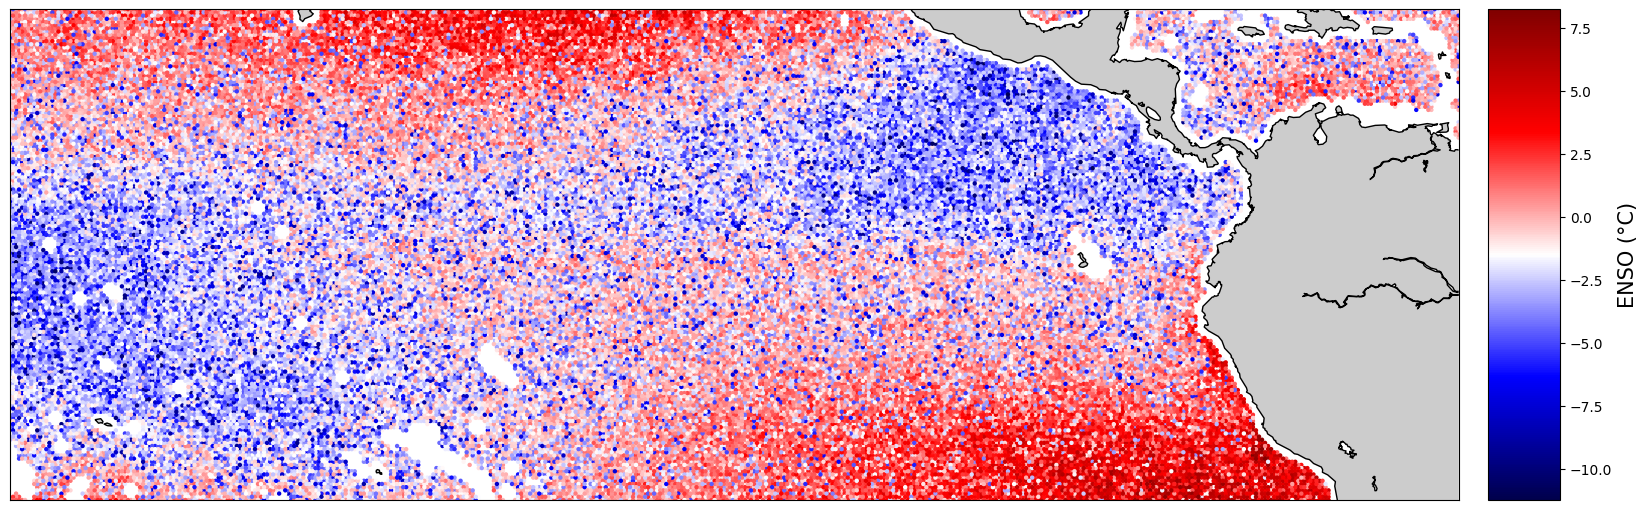

In [ ]:
plot_im(el_nino_map.lon,el_nino_map.lat,anomaly_map,10,'ENSO (°C)')

Ici on trace un la carte des température lors d'un épisode La Nina.

In [ ]:
%%bigquery data_day_LA_NINA --project alert-ground-261008
SELECT lon, lat, sst
FROM bdo2020.bdo2020.1998_2015
WHERE lon<300 and lon>180 and lat<20 and lat>-20 and time = 733045.0

Query is running:   0%|          |

Downloading:   0%|          |

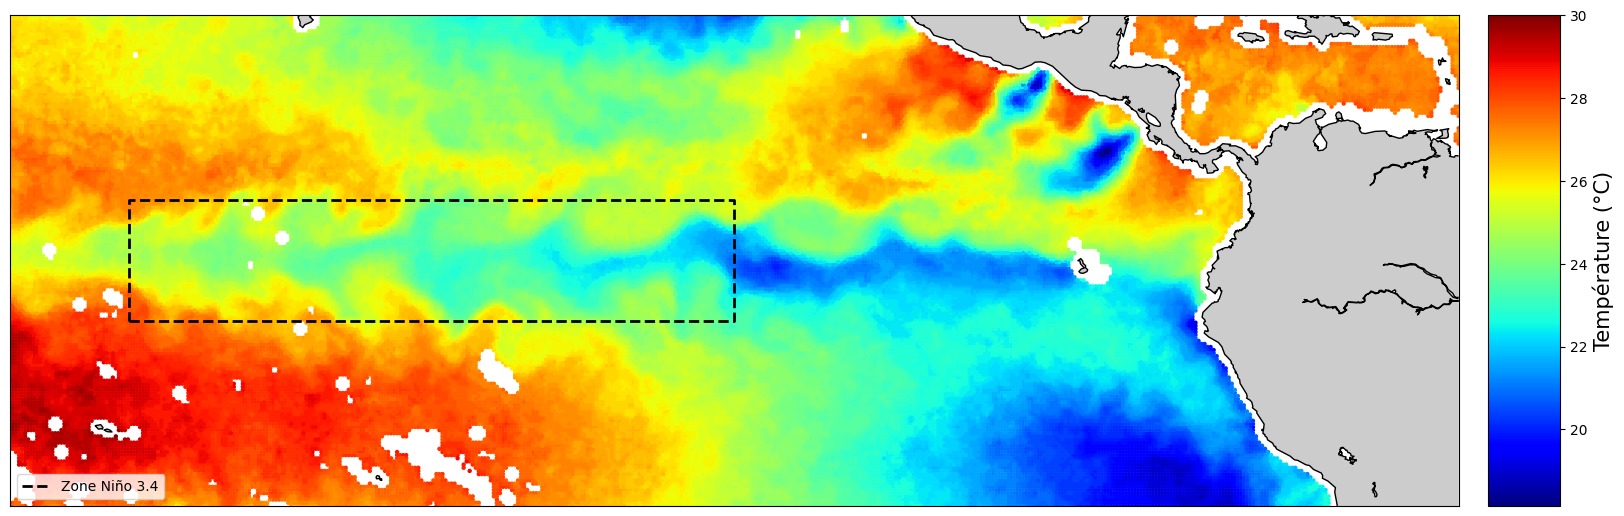

In [ ]:
lon_min_Nino34, lon_max_Nino34, lat_min_Nino34, lat_max_Nino34 = 190, 240, -5, 5
plot_im(data_day_LA_NINA.lon, data_day_LA_NINA.lat, data_day_LA_NINA.sst, 10, 'Température (°C)', rect_coords=(lon_min_Nino34, lon_max_Nino34, lat_min_Nino34, lat_max_Nino34))

## Prédiction

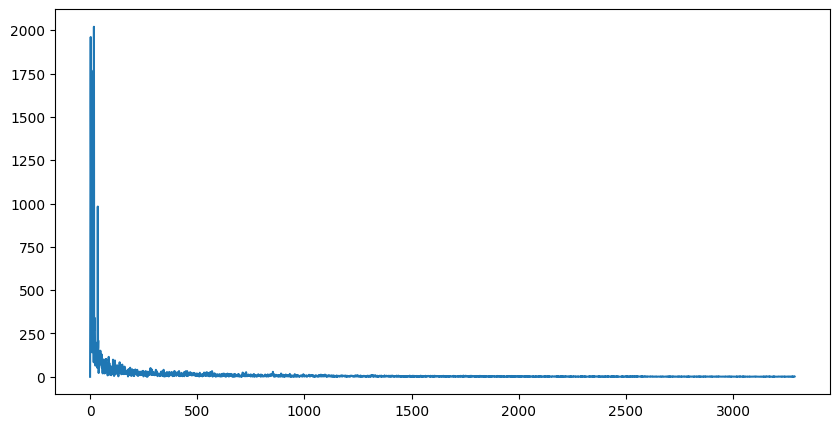

In [42]:
import numpy as np
signal_fft = np.fft.rfft(output["mean_sst"])
plt.figure(figsize=(10,5))
plt.plot(np.abs(signal_fft))

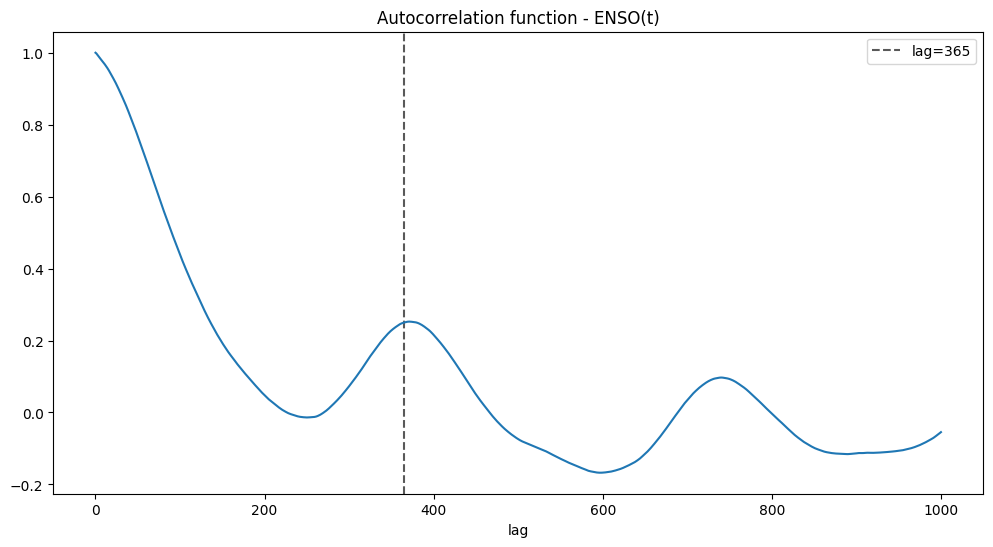

In [30]:
from statsmodels.graphics.tsaplots import acf
output = output - output.mean()
data_pac = output
autocorr_full = acf(data_pac['mean_sst'], nlags=1000)
plt.figure(figsize=(12, 6))
plt.axvline(x=365, color='black', linestyle='--', alpha=0.65, label="lag=365")
plt.title("Autocorrelation function - ENSO(t)")
plt.xlabel("lag")
plt.legend()
plt.plot(autocorr_full)

Mean Squared Error (MSE): 0.9490
R-squared (R²): -0.0145


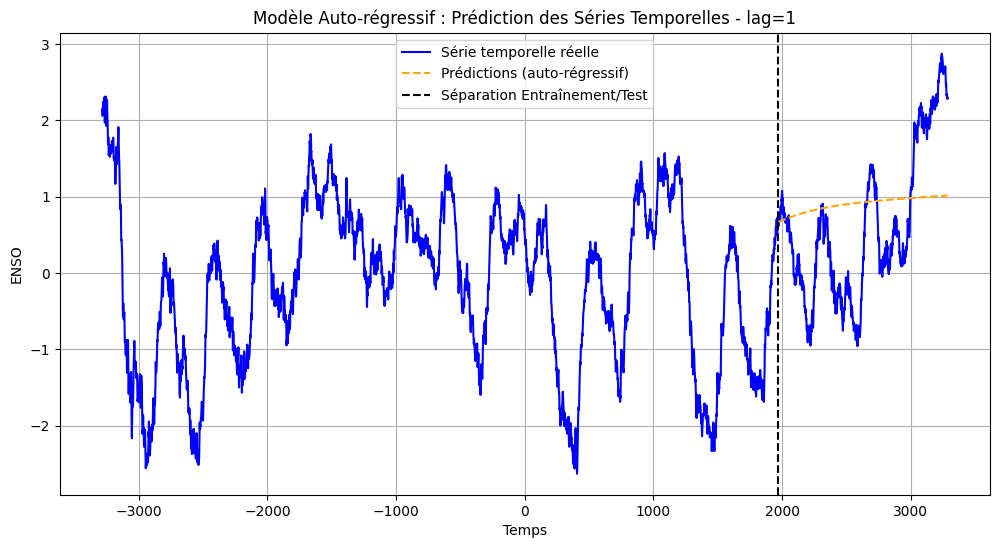

In [44]:
# Préparer les données
time = output["time"]  # Temps
enso = output["mean_sst"]  # Valeurs ENSO

look_back = 1  # Nombre de lags (ENSO(t-1))

# Créer les features avec décalage temporel
data = pd.DataFrame({
    'time': time,
    'ENSO_t-1': enso.shift(look_back)
})
data['ENSO'] = enso  # Cible ENSO actuelle

# Supprimer les lignes avec NaN dues au décalage
data = data.dropna()

# Extraire les features (time + ENSO(t-1)) et la cible
X = data[['time', 'ENSO_t-1']].values
y = data['ENSO'].values

# Transformation polynomiale pour ENSO(t-1)
degree = 3
poly = PolynomialFeatures(degree=degree, include_bias=False)
enso_poly = poly.fit_transform(X[:, 1].reshape(-1, 1))  # Appliquer seulement à ENSO(t-1)

# Combiner 'time' et les features polynomiales
X_poly = np.hstack([X[:, 0].reshape(-1, 1), enso_poly])  # Ajouter 'time' comme première colonne

# Diviser les données manuellement
train_size = int(0.8 * len(X_poly))  # 80% pour l'entraînement
X_train = X_poly[:train_size]
y_train = y[:train_size]
X_test = X_poly[train_size:]
y_test = y[train_size:]

# Entraîner le modèle
model = LinearRegression()
model.fit(X_train, y_train)

# Prédiction dynamique pour l'ensemble de test (auto-régressif)
y_pred = []
last_pred = y_train[-1]  # Initialiser avec la dernière valeur d'entraînement (cible de l'ultime train)

# Pour chaque valeur du test, prédire dynamiquement en utilisant les valeurs précédentes
for i in range(len(X_test)):
    # Créer la feature correspondante pour l'instant
    time_step = X_test[i, 0]
    enso_t_minus_1 = y_pred[-1] if len(y_pred) > 0 else y_train[-1]  # Utiliser la prédiction précédente ou la dernière valeur d'entraînement
    X_test_dynamic = np.array([[time_step, enso_t_minus_1]])

    # Transformation polynomiale
    X_test_dynamic_poly = poly.transform(X_test_dynamic[:, 1].reshape(-1, 1))
    X_test_dynamic_poly = np.hstack([X_test_dynamic[:, 0].reshape(-1, 1), X_test_dynamic_poly])

    # Prédire la valeur suivante
    next_pred = model.predict(X_test_dynamic_poly)[0]
    y_pred.append(next_pred)

# Évaluer le modèle
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R²): {r2:.4f}")

# Tracer les séries temporelles réelles et prédites
plt.figure(figsize=(12, 6))
plt.plot(data['time'], y, label='Série temporelle réelle', color='blue')
plt.plot(data['time'][train_size:], y_pred, label='Prédictions (auto-régressif)', color='orange', linestyle='--')
plt.axvline(x=data['time'].iloc[train_size], color='black', linestyle='--', label='Séparation Entraînement/Test')
plt.xlabel('Temps')
plt.ylabel('ENSO')
plt.title('Modèle Auto-régressif : Prédiction des Séries Temporelles - lag=1')
plt.legend()
plt.grid()
plt.show()


In [ ]:
data = data_pac["mean_sst"]

train_size = int(0.8 * len(data_pac))
train_data = data_pac[:train_size]
test_data = data_pac[train_size:]

y_train = train_data['mean_sst']
y_test = test_data['mean_sst']


# Set the number of lags
lag_number = 365

# Fit the AutoReg model with the specified number of lags
model = AutoReg(y_train, lags=lag_number)
ar_results = model.fit()

# Define buffer zone
n_buffer = 400
start_index = train_size + n_buffer  # Start predictions after the buffer

# Collect initial values needed for lags (from training + buffer points)
initial_lags = data[start_index - lag_number : start_index]

# Dynamically predict starting from `start_index` using past predictions
dynamic_predictions_mean = []
dynamic_predictions_std = []
errors = []
current_values = initial_lags.tolist()

# Predict dynamically for the remaining test data
for i in range(len(data) - start_index):
    next_pred_mean = ar_results.params[0] 
    for lag_idx in range(1, lag_number + 1): 
        next_pred_mean += ar_results.params[lag_idx] * current_values[-lag_idx]

    dynamic_predictions_mean.append(next_pred_mean)
    errors.append(next_pred_mean - data[start_index + i])
    current_values.append(next_pred_mean)
    current_values.pop(0)



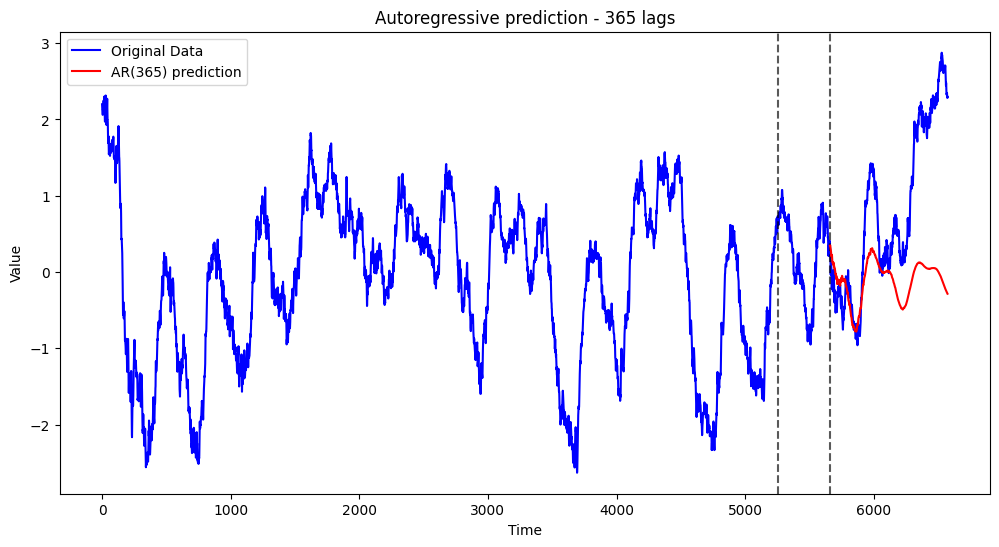

In [34]:
plt.figure(figsize=(12, 6))
plt.plot(data, label='Original Data', color='blue')
plt.axvline(x=train_size, color='black', linestyle='--', alpha=0.65)
plt.axvline(x=train_size+n_buffer, color='black', linestyle='--', alpha=0.65)
plt.plot(range(start_index, len(data)), dynamic_predictions_mean, label=f'AR({lag_number}) prediction', color='red')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title(f'Autoregressive prediction - {lag_number} lags')
plt.legend()
plt.show()

## Error modeling

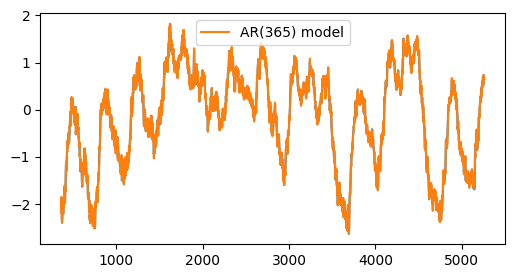

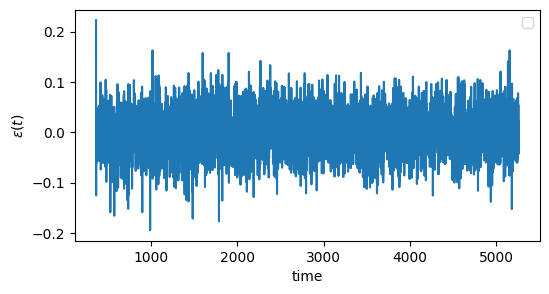

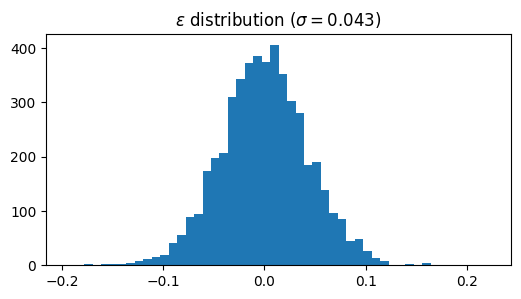

mu_eta = 8.280167633595875e-16
sigma_eta = 0.04295708654952938


Text(0, 0.5, '$\\epsilon(t+1)$')

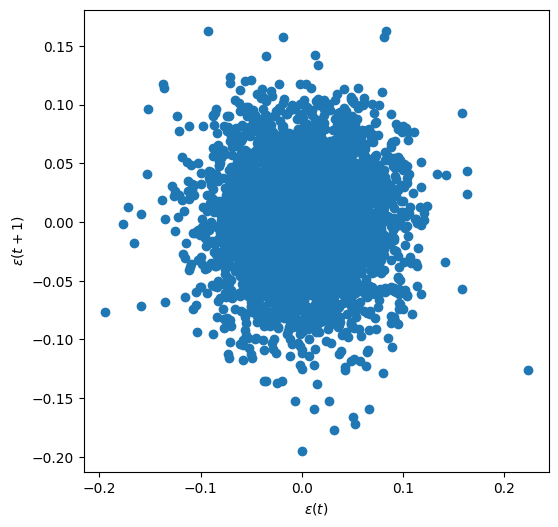

In [ ]:
y_pred_on_train = ar_results.predict(start=365, end=len(y_train)-1, dynamic=False)

plt.figure(figsize=(6,3))
plt.plot(y_train[365:])
plt.plot(y_pred_on_train, label='AR(365) model')
plt.legend()
plt.show()

mse = mean_squared_error(y_train[365:], y_pred_on_train)

errors = y_train[365:] - y_pred_on_train
mu_eta = np.mean(errors)
sigma_eta = np.std(errors)

plt.figure(figsize=(6,3))
plt.plot(errors)
plt.xlabel("time")
plt.ylabel("$\epsilon(t)$")


plt.legend()
plt.show()
plt.figure(figsize=(6,3))
plt.hist(errors, bins=50)
plt.title(f"$\epsilon$ distribution ($\sigma = {round(sigma_eta,3)}$)")
plt.show()


print(f"mu_eta = {mu_eta}")
print(f"sigma_eta = {sigma_eta}")

plt.figure(figsize=(6, 6))
plt.scatter(errors[:-1], errors[1:])
plt.xlabel("$\epsilon(t)$")
plt.ylabel("$\epsilon(t+1)$")

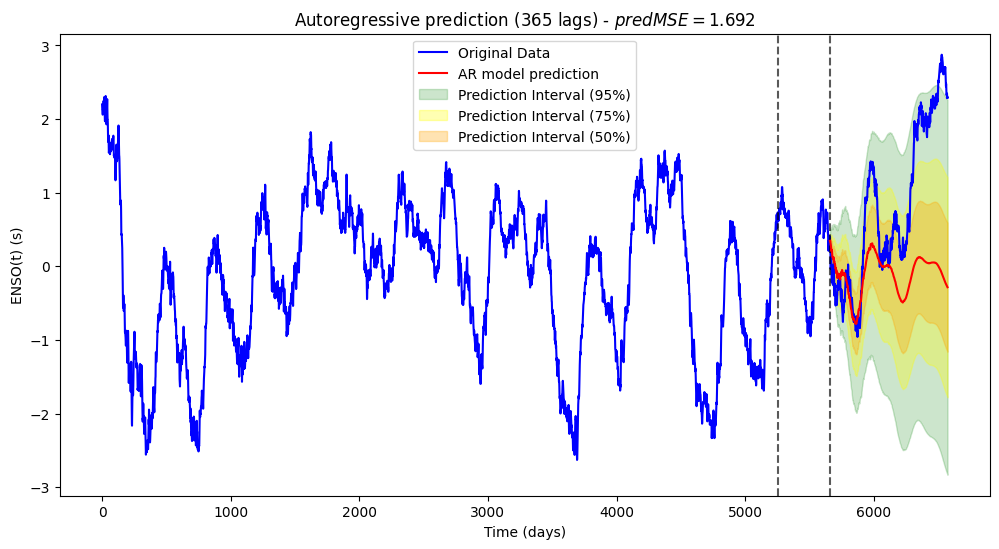

In [ ]:
pred_mse = mean_squared_error(data[start_index:], dynamic_predictions_mean)

time = data_pac["time"]


errors_var = np.zeros(len(data) - start_index)
errors_var[0] = mse


for i in range(len(errors_var)-1):
  errors_var[i+1] = errors_var[i] + sigma_eta**2
errors_std = np.sqrt(errors_var)


# Plot the dynamic predictions
plt.figure(figsize=(12, 6))
plt.plot(data, label='Original Data', color='blue')
plt.axvline(x=train_size, color='black', linestyle='--', alpha=0.65)
plt.axvline(x=train_size+n_buffer, color='black', linestyle='--', alpha=0.65)
plt.plot(range(start_index, len(data)), dynamic_predictions_mean, label='AR model prediction', color='red', linestyle='-')

plt.fill_between(range(start_index, len(data)), dynamic_predictions_mean + 1.96*errors_std, dynamic_predictions_mean - 1.96*errors_std, alpha=0.2, label="Prediction Interval (95%)", color="green")
plt.fill_between(range(start_index, len(data)), dynamic_predictions_mean + 1.150*errors_std, dynamic_predictions_mean - 1.150*errors_std, alpha=0.3, label="Prediction Interval (75%)", color="yellow")
plt.fill_between(range(start_index, len(data)), dynamic_predictions_mean + 0.674*errors_std, dynamic_predictions_mean - 0.674*errors_std, alpha=0.3, label="Prediction Interval (50%)", color="orange")

plt.xlabel('Time (days)')
plt.ylabel('ENSO(t) (s)')
plt.title(f'Autoregressive prediction (365 lags) - $predMSE = {round(pred_mse,3)}$')
plt.legend()
plt.show()


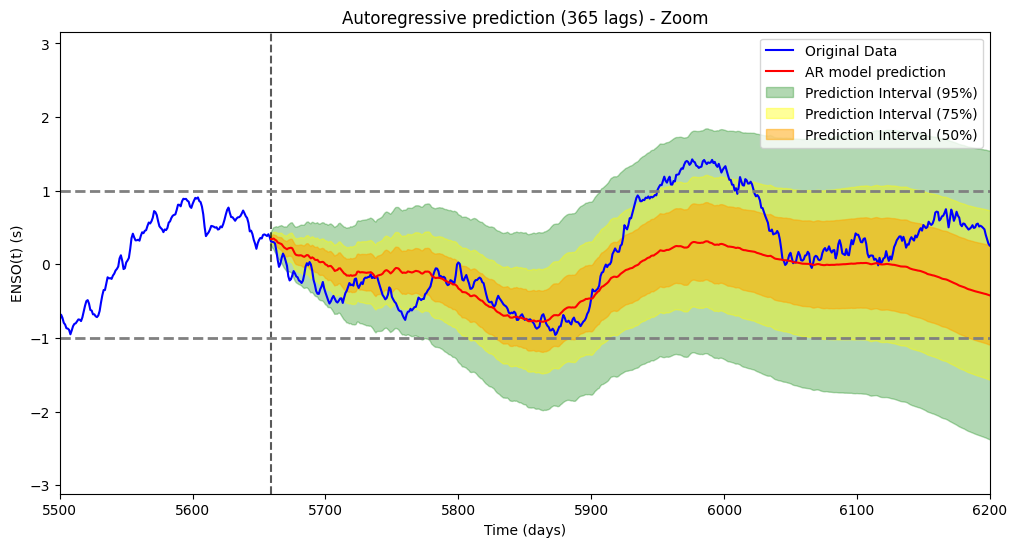

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(data, label='Original Data', color='blue')
plt.axvline(x=train_size, color='black', linestyle='--', alpha=0.65)
plt.axvline(x=train_size+n_buffer, color='black', linestyle='--', alpha=0.65)
plt.plot(range(start_index, len(data)), dynamic_predictions_mean, label='AR model prediction', color='red', linestyle='-')
plt.fill_between(range(start_index, len(data)), dynamic_predictions_mean + 1.96*errors_std, dynamic_predictions_mean - 1.96*errors_std, alpha=0.3, label="Prediction Interval (95%)", color="green")
plt.fill_between(range(start_index, len(data)), dynamic_predictions_mean + 1.150*errors_std, dynamic_predictions_mean - 1.150*errors_std, alpha=0.4, label="Prediction Interval (75%)", color="yellow")
plt.fill_between(range(start_index, len(data)), dynamic_predictions_mean + 0.674*errors_std, dynamic_predictions_mean - 0.674*errors_std, alpha=0.5, label="Prediction Interval (50%)", color="orange")
plt.axhline(y=1, color='grey', linestyle='--', linewidth=2)
plt.axhline(y=-1, color='grey', linestyle='--', linewidth=2)
plt.xlabel('Time (days)')
plt.ylabel('ENSO(t) (s)')
plt.title('Autoregressive prediction (365 lags) - Zoom')
plt.legend()
plt.xlim(5500,6200)
plt.show()